In [1]:
import numpy as np
import pandas as pd 
from torchvision import datasets, transforms
import torch.nn as nn
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn
from torch.utils.data import   DataLoader
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    root=r"fruits_dataset_large\train",
    transform=train_transform
)


test_dataset = datasets.ImageFolder(
    root=r"fruits_dataset_large\test",
    transform=test_transform
)




In [3]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [4]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

image, labels = next(iter(train_loader))



['Amaranth', 'Apple', 'Apricot', 'Asparagus', 'Avocado', 'Banana', 'Beans', 'Beetroot', 'Bell Pepper', 'Bitter Gourd', 'Black Berry', 'Black Current', 'Blackberry', 'Blueberry', 'Bottle Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cashew', 'Cauliflower', 'Chikoo', 'Chilli', 'Chilli Peper', 'Coconut', 'Corn', 'Cranberry', 'Cucumber', 'Custard Apple', 'Dates', 'Dragon Fruit', 'Dragonfruit', 'Eggplant', 'Elderberry', 'Fig', 'Garlic', 'Ginger', 'Gooseberry', 'Grapes', 'Guava', 'Jackfruit', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Litchi', 'Longan', 'Mango', 'Mushroom', 'Muskmelon', 'Okra', 'Olive', 'Onion', 'Orange', 'Papaya', 'Paprika', 'Passion Fruit', 'Peach', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Plum', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Radish', 'Rambutan', 'Raspberry', 'Ridge Gourd', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweet Potato', 'Sweetcorn', 'Sweetpotato', 'Tamarind', 'Taro Roots', 'Tinda', 'Tomato', 'Turnip', 'Watermelon', 'Wax Gourd', 'Wo

In [5]:
# images, labels = next(iter(train_loader))

# print(images.shape)

In [6]:
# creating model
class my_cnn(nn.Module):
    def __init__(self,num_feature,num_classes):
        super().__init__()
        
        self.features=nn.Sequential(
            nn.Conv2d(num_feature,64,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128,256,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            
            nn.AdaptiveAvgPool2d((1, 1))
            )
       
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x):
        output=self.features(x)
        output=self.classifier(output)
    
        return output
        

In [7]:
epochs=120
learning_rate=0.001
print(len(train_dataset.classes))
model=my_cnn(3, len(train_dataset.classes))
model=model.to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=learning_rate)

88


In [8]:
from tqdm import tqdm

# training pipeline
for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    )

    for image, labels in progress:

        image, labels = image.to(device), labels.to(device)

        output = model(image)

        loss = criterion(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

        progress.set_postfix(loss=f"{loss.item():.5f}")

    avg_train_loss = total_epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {avg_train_loss:.5f}"
    )

Epoch 1/120: 100%|██████████| 538/538 [01:03<00:00,  8.43it/s, loss=2.13795]


Epoch [1/120] | Train Loss: 2.65433


Epoch 2/120: 100%|██████████| 538/538 [01:04<00:00,  8.36it/s, loss=2.07086]


Epoch [2/120] | Train Loss: 1.99827


Epoch 3/120: 100%|██████████| 538/538 [01:06<00:00,  8.05it/s, loss=1.75109]


...

Epoch [118/120] | Train Loss: 0.47099


Epoch 119/120: 100%|██████████| 538/538 [01:13<00:00,  7.29it/s, loss=0.42555]


Epoch [119/120] | Train Loss: 0.46698


Epoch 120/120: 100%|██████████| 538/538 [01:11<00:00,  7.55it/s, loss=0.87474]

Epoch [120/120] | Train Loss: 0.46455


In [9]:
# Model Evaluation

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_feature, batchlabel in train_loader:

        batch_feature = batch_feature.to(device)
        batchlabel = batchlabel.to(device)

        # model prediction
        output = model(batch_feature)

        # get predicted class
        _, predicted = torch.max(output, 1)

        # Count correct predictions
        total += batchlabel.size(0)
        correct += (predicted == batchlabel).sum().item()


accuracy = 100 * correct / total

print("MODEL PERFORMANCE CHECK")
print("Correct Predictions :", correct)
print("Total Images        :", total)
print(f"Accuracy            : {accuracy:.2f}%")

MODEL PERFORMANCE CHECK
Correct Predictions : 62408
Total Images        : 68836
Accuracy            : 90.66%


In [10]:
# Replace your Cell 10
# Model Evaluation
model.eval()

correct = 0
total = 0

with torch.no_grad():
    # FIXED: Iterate over test_loader instead of train_loader
    for batch_feature, batchlabel in test_loader: 

        batch_feature = batch_feature.to(device)
        batchlabel = batchlabel.to(device)

        # Model prediction
        output = model(batch_feature)

        # Get predicted class
        _, predicted = torch.max(output, 1)

        # Count correct predictions
        total += batchlabel.size(0)
        correct += (predicted == batchlabel).sum().item()

# Calculate accuracy
accuracy = 100 * correct / total

print("MODEL PERFORMANCE ON UNSEEN TEST DATA")
print("Correct Predictions :", correct)
print("Total Images        :", total)
print(f"Accuracy            : {accuracy:.2f}%")

MODEL PERFORMANCE ON UNSEEN TEST DATA
Correct Predictions : 10968
Total Images        : 14980
Accuracy            : 73.22%


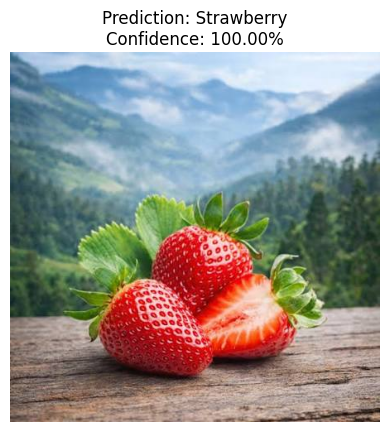

Predicted Fruit : Strawberry
Confidence      : 100.00%


In [11]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_fruit(image_path, model, class_names, device):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used during training
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        )
    ])

    # Transform image
    image_tensor = transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(image_tensor)

        probabilities = torch.softmax(output, dim=1)

        predicted_class = torch.argmax(probabilities, dim=1).item()

        confidence = probabilities[0][predicted_class].item() * 100

    # Display image
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("Predicted Fruit :", class_names[predicted_class])
    print(f"Confidence      : {confidence:.2f}%")
    
    

predict_fruit(
    "fruit.jpg",
    model,
    train_dataset.classes,
    device
)

In [13]:
torch.save(model.state_dict(),"fruit_classification.pth")
import json
class_names=train_dataset.classes
with open("class_names.json", "w") as f:
    json.dump(class_names, f)